# LAB1 Kuan-Chen, Chen

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from pandas.plotting import scatter_matrix
from scipy import stats


## A.UF Dataset


### B.

In [2]:
data = np.load(r"C:\Users\champ\OneDrive\文件\GitHub\lab-01-Ckcinnabar\UF_data.npy")

In [3]:
data

array([[-1.47777778,  1.40606061,  1.        ],
       [-1.35454545,  0.6969697 ,  1.        ],
       [-1.33636364,  1.28787879,  1.        ],
       ...,
       [ 0.86242424, -1.05252525,  0.        ],
       [ 0.99818182, -1.06060606,  0.        ],
       [ 0.86525253, -1.10707071,  0.        ]])

In [4]:
data.shape

(3000, 3)

In [5]:
x = data[:,0] 
y = data[:,1]
z = data[:,2]

### C.

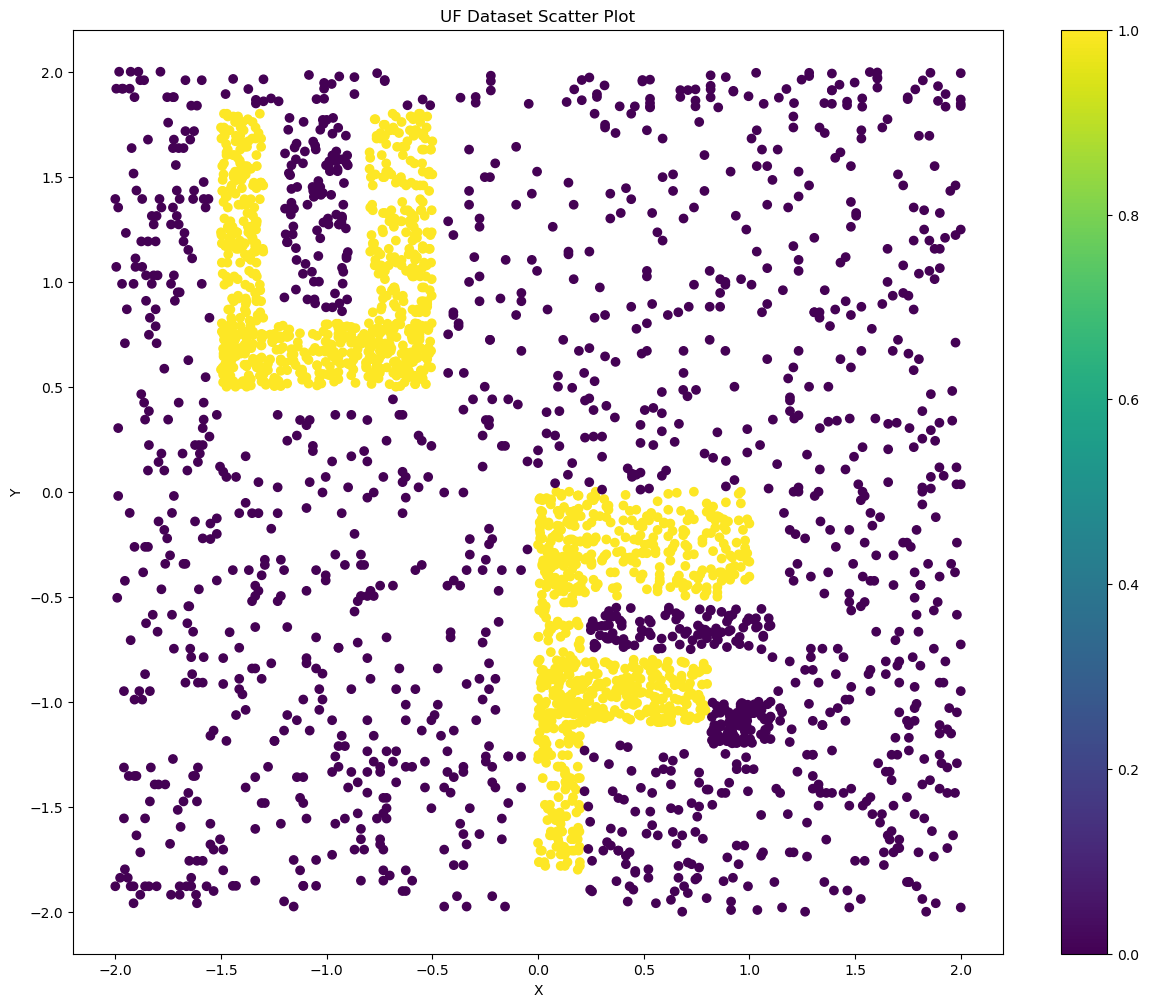

In [6]:
plt.figure(figsize=(15, 12))
plt.scatter(x, y, c = z)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("UF Dataset Scatter Plot")
plt.colorbar()
plt.show()

## A. Computer Hardware Dataset

In [7]:
df = pd.read_csv(r"C:\Users\champ\OneDrive\文件\GitHub\lab-01-Ckcinnabar\computer_hardware.csv")

In [8]:
df

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,RP
0,125,256,6000,256,16,128,198
1,29,8000,32000,32,8,32,269
2,29,8000,32000,32,8,32,220
3,29,8000,32000,32,8,32,172
4,29,8000,16000,32,8,16,132
...,...,...,...,...,...,...,...
204,124,1000,8000,0,1,8,42
205,98,1000,8000,32,2,8,46
206,125,2000,8000,0,2,14,52
207,480,512,8000,32,0,0,67


### B.

In [9]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)
df = pd.DataFrame(df_scaled, columns=df.columns)
df

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,RP
0,0.072825,0.006012,0.092843,1.000,0.307692,0.727273,0.167832
1,0.008092,0.248497,0.499499,0.125,0.153846,0.181818,0.229895
2,0.008092,0.248497,0.499499,0.125,0.153846,0.181818,0.187063
3,0.008092,0.248497,0.499499,0.125,0.153846,0.181818,0.145105
4,0.008092,0.248497,0.249249,0.125,0.153846,0.090909,0.110140
...,...,...,...,...,...,...,...
204,0.072151,0.029309,0.124124,0.000,0.019231,0.045455,0.031469
205,0.054619,0.029309,0.124124,0.125,0.038462,0.045455,0.034965
206,0.072825,0.060621,0.124124,0.000,0.038462,0.079545,0.040210
207,0.312205,0.014028,0.124124,0.125,0.000000,0.000000,0.053322


### C.

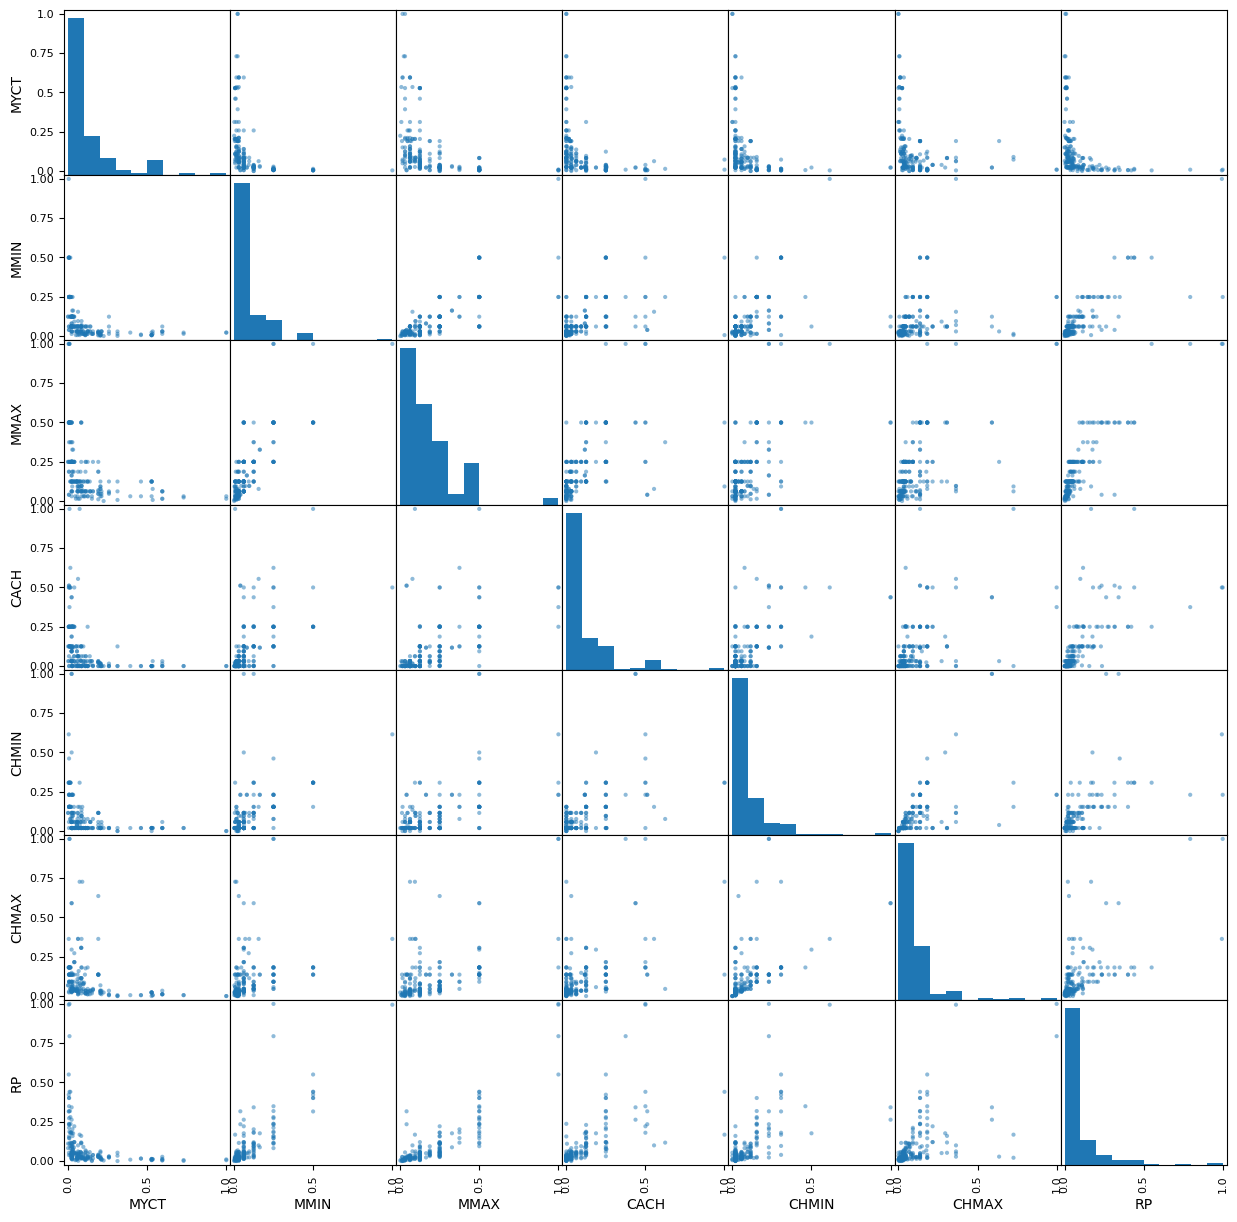

In [10]:
scatter_matrix(df, figsize=(15, 15))
plt.show()

### D.

In [11]:
corr_matrix = df.corr(method="pearson",numeric_only=True)
corr_matrix

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,RP
MYCT,1.000000,-0.335642,-0.378561,-0.321000,-0.301090,-0.250502,-0.307099
MMIN,-0.335642,1.000000,0.758157,0.534729,0.517189,0.266907,0.794931
MMAX,-0.378561,0.758157,1.000000,0.537990,0.560513,0.527246,0.863004
CACH,-0.321000,0.534729,0.537990,1.000000,0.582245,0.487846,0.662641
CHMIN,-0.301090,0.517189,0.560513,0.582245,1.000000,0.548281,0.608903
CHMAX,-0.250502,0.266907,0.527246,0.487846,0.548281,1.000000,0.605209
RP,-0.307099,0.794931,0.863004,0.662641,0.608903,0.605209,1.000000


In [16]:
for col in corr_matrix.columns:
   print(f"\nCorrelations for {col}:")
   print(corr_matrix[col].sort_values(ascending=False))


Correlations for MYCT:
MYCT     1.000000
CHMAX   -0.250502
CHMIN   -0.301090
RP      -0.307099
CACH    -0.321000
MMIN    -0.335642
MMAX    -0.378561
Name: MYCT, dtype: float64

Correlations for MMIN:
MMIN     1.000000
RP       0.794931
MMAX     0.758157
CACH     0.534729
CHMIN    0.517189
CHMAX    0.266907
MYCT    -0.335642
Name: MMIN, dtype: float64

Correlations for MMAX:
MMAX     1.000000
RP       0.863004
MMIN     0.758157
CHMIN    0.560513
CACH     0.537990
CHMAX    0.527246
MYCT    -0.378561
Name: MMAX, dtype: float64

Correlations for CACH:
CACH     1.000000
RP       0.662641
CHMIN    0.582245
MMAX     0.537990
MMIN     0.534729
CHMAX    0.487846
MYCT    -0.321000
Name: CACH, dtype: float64

Correlations for CHMIN:
CHMIN    1.000000
RP       0.608903
CACH     0.582245
MMAX     0.560513
CHMAX    0.548281
MMIN     0.517189
MYCT    -0.301090
Name: CHMIN, dtype: float64

Correlations for CHMAX:
CHMAX    1.000000
RP       0.605209
CHMIN    0.548281
MMAX     0.527246
CACH     0.48784

### E.MMAX and RP, the correlations between them are 0.863

### F.

In [13]:
x = df["MMAX"]
y = df["RP"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")

Slope: 0.6615
Intercept: -0.0343
R-squared: 0.7448


### G.

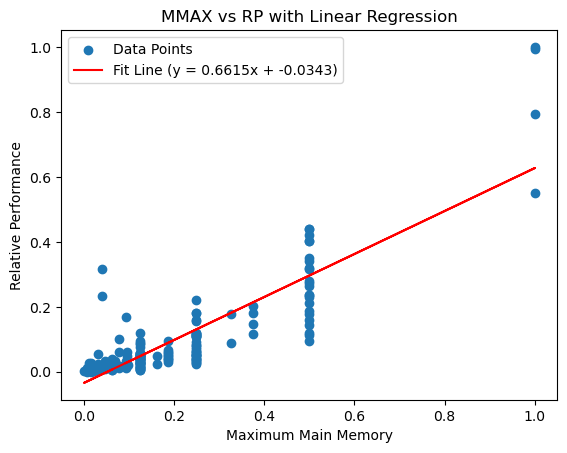

In [17]:
scatter = plt.scatter(x, y)
line = plt.plot(x, slope * x + intercept, "r")

plt.xlabel("Maximum Main Memory")
plt.ylabel("Relative Performance")
plt.title("MMAX vs RP with Linear Regression")

plt.legend((scatter, line[0]), ("Data Points", f"Fit Line (y = {slope:.4f}x + {intercept:.4f})"))
plt.show()